<a href="https://colab.research.google.com/github/AlekhyaGangopadhyay/IEM-IIT_HCI_Project/blob/main/Implementing_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: Install & Import
!pip install openpyxl -q

import os, time
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from google.colab import files

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [ ]:
# STEP 2: Upload your .xlsx file
print('Please upload your EEG .xlsx file...')
uploaded = files.upload()

INPUT_FILE = next(iter(uploaded))           # e.g. 'ARROW_Forward.xlsx'
BASE_NAME  = os.path.splitext(INPUT_FILE)[0]  # e.g. 'ARROW_Forward'
print(f'\nLoaded file : {INPUT_FILE}')

df         = pd.read_excel(INPUT_FILE, engine='openpyxl')
col_names  = list(df.columns)
signal     = df.values.astype(np.float32)

N_CHANNELS    = signal.shape[1]    # auto-detected (should be 20)
TOTAL_SAMPLES = signal.shape[0]    # auto-detected (should be 10240)
print(f'Shape       : {signal.shape}  →  {TOTAL_SAMPLES} samples × {N_CHANNELS} channels')
print(f'Columns     : {col_names}')

Please upload your EEG .xlsx file...


Saving WORD_Right.xlsx to WORD_Right.xlsx

Loaded file : WORD_Right.xlsx
Shape       : (10240, 20)  →  10240 samples × 20 channels
Columns     : ['FP2- F8', 'F8 - T4', 'T4 - T6', 'T6 - O2', 'FP2- F4', 'F4 - C4', 'C4 - P4', 'P4 - O2', 'FP1- F7', 'F7 - T3', 'T3 - T5', 'T5 - O1', 'FP1- F3', 'F3 - C3', 'C3 - P3', 'P3 - O1', 'FZ - CZ', 'CZ - PZ', 'BP1- REF', 'BP2- REF']


In [ ]:
# STEP 3: Config  (no need to change anything here)
N_SYNTHETIC      = 4
WINDOW_SIZE      = 64       # small window → fast training
STRIDE           = 16       # 75% overlap → ~630 training windows
LATENT_DIM       = 64
BATCH_SIZE       = 64
NUM_EPOCHS       = 300
LR               = 0.0002
N_CRITIC         = 3
LAMBDA_GP        = 10

FEATURE_DIM      = WINDOW_SIZE * N_CHANNELS          # 64×20 = 1280
WINDOWS_PER_FILE = TOTAL_SAMPLES // WINDOW_SIZE       # 160  (for reconstruction)

print(f'Feature dim     : {FEATURE_DIM}')
print(f'Training windows: {len(range(0, TOTAL_SAMPLES - WINDOW_SIZE + 1, STRIDE))}')
print(f'Recon windows   : {WINDOWS_PER_FILE}  →  {WINDOWS_PER_FILE * WINDOW_SIZE} samples output')

Feature dim     : 1280
Training windows: 637
Recon windows   : 160  →  10240 samples output


In [ ]:
# STEP 4: Sliding-window segmentation + Normalise + DataLoader
def sliding_windows(sig, win, stride):
    starts = range(0, len(sig) - win + 1, stride)
    return np.stack([sig[s:s+win].flatten() for s in starts])

windows = sliding_windows(signal, WINDOW_SIZE, STRIDE)
print(f'Windows shape: {windows.shape}')

scaler  = StandardScaler()
X       = torch.tensor(scaler.fit_transform(windows).astype(np.float32))
loader  = DataLoader(TensorDataset(X), batch_size=BATCH_SIZE,
                     shuffle=True, drop_last=True)
print(f'Batches/epoch: {len(loader)}')

Windows shape: (637, 1280)
Batches/epoch: 9


In [ ]:
# STEP 5: WGAN-GP Model Definitions
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, FEATURE_DIM),
            nn.Tanh()
        )
    def forward(self, z): return self.net(z)


class Critic(nn.Module):
    """No Sigmoid — outputs unbounded score."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(FEATURE_DIM, 1024),
            nn.LayerNorm(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),  nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LayerNorm(256),  nn.LeakyReLU(0.2),
            nn.Linear(256, 1)   # no Sigmoid
        )
    def forward(self, x): return self.net(x)


def gradient_penalty(C, real, fake):
    bs    = real.size(0)
    alpha = torch.rand(bs, 1, device=device).expand_as(real)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    grad   = torch.autograd.grad(
        C(interp), interp,
        grad_outputs=torch.ones(bs, 1, device=device),
        create_graph=True, retain_graph=True
    )[0]
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()


print('Models defined.')

Models defined.


In [ ]:
# STEP 6: Train WGAN-GP
G = Generator().to(device)
C = Critic().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.0, 0.9))
opt_C = torch.optim.Adam(C.parameters(), lr=LR, betas=(0.0, 0.9))

G_losses, C_losses, W_dists = [], [], []

print(f'Training for {NUM_EPOCHS} epochs...')
print('Healthy sign: W-dist should rise and stabilise at a positive value\n')
t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    for (real_x,) in loader:
        real_x = real_x.to(device)
        bs     = real_x.size(0)

        # Train Critic N_CRITIC times
        for _ in range(N_CRITIC):
            noise  = torch.randn(bs, LATENT_DIM, device=device)
            fake_x = G(noise).detach()
            sr, sf = C(real_x).mean(), C(fake_x).mean()
            gp     = gradient_penalty(C, real_x, fake_x)
            c_loss = -sr + sf + LAMBDA_GP * gp
            opt_C.zero_grad(); c_loss.backward(); opt_C.step()

        # Train Generator once
        noise  = torch.randn(bs, LATENT_DIM, device=device)
        g_loss = -C(G(noise)).mean()
        opt_G.zero_grad(); g_loss.backward(); opt_G.step()

    W_dists.append((sr - sf).item())
    G_losses.append(g_loss.item())
    C_losses.append(c_loss.item())

    if epoch % 50 == 0:
        elapsed = (time.time() - t0) / 60
        print(f'  Epoch {epoch:3d}/{NUM_EPOCHS}  '
              f'W-dist={W_dists[-1]:+.4f}  '
              f'G={G_losses[-1]:.4f}  '
              f'C={C_losses[-1]:.4f}  '
              f'[{elapsed:.1f} min elapsed]')

print(f'\nTraining complete in {(time.time()-t0)/60:.1f} min')

Training for 300 epochs...
Healthy sign: W-dist should rise and stabilise at a positive value

  Epoch  50/300  W-dist=+30.6095  G=17.9467  C=-21.4483  [2.4 min elapsed]
  Epoch 100/300  W-dist=+32.7590  G=23.2061  C=-25.5771  [4.9 min elapsed]
  Epoch 150/300  W-dist=+34.9699  G=25.4102  C=-25.1257  [7.3 min elapsed]
  Epoch 200/300  W-dist=+33.5619  G=29.6060  C=-24.5645  [9.7 min elapsed]
  Epoch 250/300  W-dist=+39.1431  G=33.5715  C=-25.5301  [12.2 min elapsed]
  Epoch 300/300  W-dist=+39.0998  G=36.4661  C=-28.4958  [14.6 min elapsed]

Training complete in 14.6 min


In [ ]:
# STEP 8: Generate 4 synthetic files & download them
def generate_synthetic():
    G.eval()
    with torch.no_grad():
        noise     = torch.randn(WINDOWS_PER_FILE, LATENT_DIM, device=device)
        fake_wins = G(noise).cpu().numpy()              # (160, 1280)
        fake_wins = scaler.inverse_transform(fake_wins) # undo scaling
    # reshape (160, 64, 20) → (10240, 20)
    fake_signal = (fake_wins
                   .reshape(WINDOWS_PER_FILE, WINDOW_SIZE, N_CHANNELS)
                   .reshape(TOTAL_SAMPLES, N_CHANNELS))
    return np.round(fake_signal).astype(int)

print(f'Generating {N_SYNTHETIC} synthetic files for  "{BASE_NAME}"...')
for n in range(1, N_SYNTHETIC + 1):
    out_name = f'{BASE_NAME}_synthetic_{n}.xlsx'
    fake     = generate_synthetic()
    pd.DataFrame(fake, columns=col_names).to_excel(out_name, index=False, engine='openpyxl')
    files.download(out_name)
    print(f'  Downloaded: {out_name}  shape={fake.shape}')

print('\nDone! Check your downloads folder.')

Generating 4 synthetic files for  "WORD_Right"...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: WORD_Right_synthetic_1.xlsx  shape=(10240, 20)


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: WORD_Right_synthetic_3.xlsx  shape=(10240, 20)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: WORD_Right_synthetic_4.xlsx  shape=(10240, 20)

Done! Check your downloads folder.


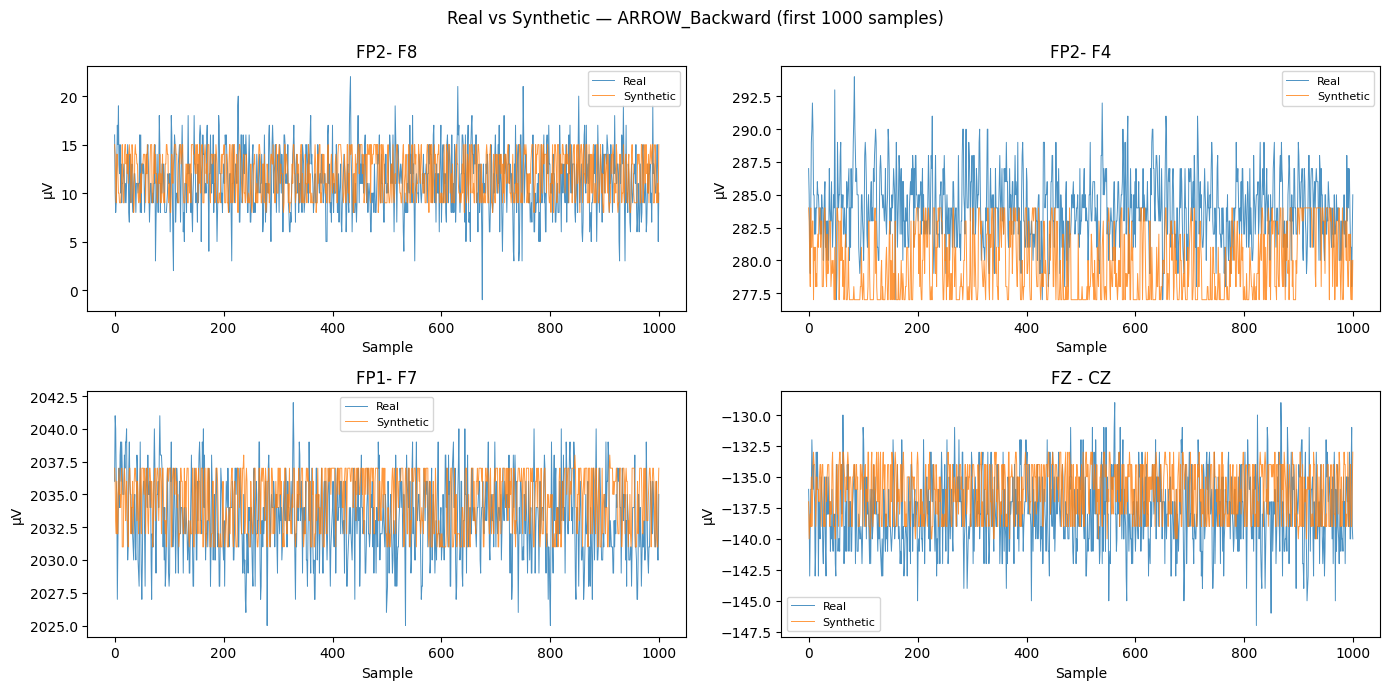


Channel                  Real µ      Syn µ     Real σ      Syn σ
------------------------------------------------------------
FP2- F8                    11.7       11.9        3.2        2.4
F8 - T4                   -22.3      -22.4        3.3        2.5
T4 - T6                  -191.2     -191.1        2.9        2.2
T6 - O2                  -245.2     -245.3        2.7        2.0
FP2- F4                   280.3      280.4        3.6        2.7
F4 - C4                 -1103.6    -1103.7        2.9        2.2
C4 - P4                   681.6      681.5        2.9        2.1
P4 - O2                  -305.2     -305.3        2.8        2.0
FP1- F7                  2034.3     2034.3        3.1        2.3
F7 - T3                  -585.0     -584.9        2.7        2.0
T3 - T5                   402.1      402.0        3.2        2.3
T5 - O1                  -204.5     -204.4        3.3        2.6
FP1- F3                  1231.8     1231.8        2.8        2.0
F3 - C3                  -40

In [ ]:
# STEP 9: Quick Sanity Check — Real vs Synthetic (channel plots)
syn_check = pd.read_excel(f'{BASE_NAME}_synthetic_1.xlsx', engine='openpyxl').values.astype(np.float32)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle(f'Real vs Synthetic — {BASE_NAME} (first 1000 samples)')
for ax, ch in zip(axes.flat, [0, 4, 8, 16]):
    ax.plot(signal   [:1000, ch], lw=0.7, alpha=0.8, label='Real')
    ax.plot(syn_check[:1000, ch], lw=0.7, alpha=0.8, label='Synthetic')
    ax.set_title(col_names[ch]); ax.legend(fontsize=8)
    ax.set_xlabel('Sample'); ax.set_ylabel('µV')
plt.tight_layout(); plt.show()

# Channel stats
print(f'\n{"Channel":20s} {"Real µ":>10s} {"Syn µ":>10s} {"Real σ":>10s} {"Syn σ":>10s}')
print('-'*60)
for i, ch in enumerate(col_names):
    print(f'{ch:20s} {signal[:,i].mean():10.1f} {syn_check[:,i].mean():10.1f} '
          f'{signal[:,i].std():10.1f} {syn_check[:,i].std():10.1f}')